In [1]:
import torch
import pickle
import pandas as pd
import os
from collections import defaultdict, Counter
import re
import time
from tqdm.notebook import tqdm
import copy
import torch.nn.functional as F

In [2]:
def tokenize_pol(snt):
    snt = snt.lower()
    snt = re.sub(r"""([\]?:)\[(/\.\-,%\$"!])""", r" \1 ", snt)
    snt = re.sub(r"\s+", " ", snt).strip()
    return re.split(r'\s+', snt.strip())

In [3]:
def tokenize_eng(snt):
    snt = snt.lower()
    snt = re.sub("(?<! )'(?! )", r" '", snt)
    snt = re.sub(r"""([\]?:)\[(/\.\-,%\$"!])""", r" \1 ", snt)
    snt = re.sub(r"\s+", " ", snt).strip()
    return re.split(r'\s+', snt.strip())

In [4]:
class BPETokenizer():
    def __init__(self, vocab_chrs, vocab_pairs, vocab_size, is_tgt):
        self.vocab_chrs = vocab_chrs
        self.vocab_pairs = vocab_pairs
        self.vocab_size = vocab_size
        self.pair_counts = self.pair_counts_init(vocab_pairs)
        self.vocab = self.vocab_init(vocab_chrs, is_tgt)
        self.base_size = len(self.vocab)

    def vocab_init(self, vocab_chrs, is_tgt):
        vocab = {'<pad>': 0, '<unk>': 1, '<eos>': 2, '_': 3}
        if is_tgt:
            vocab['<bos>'] = 4
            
        uniq_toks = {tok for toks, _ in vocab_chrs for tok in toks}
        uniq_toks.remove('_')
        for i, tok in enumerate(uniq_toks, len(vocab)):
            vocab[tok] = i
        return vocab

    def pair_counts_init(self, vocab_pairs):
        pair_counts = defaultdict(int)
        for toks, freq in vocab_pairs:
            for pair in toks:
                pair_counts[pair] += freq
        return pair_counts

    def train_bpe(self):
        for i in tqdm(range(self.base_size, self.vocab_size)):
            pair = self.most_common_pair()
            self.vocab[pair] = i
            self.replace_pairs(pair)

    def replace_pairs(self, pair):
        pair_con = f"{pair[0]}{pair[1]}"
        p_1, p_2 = map(re.escape, pair)
        
        for i in range(len(self.vocab_chrs)):
            if pair in self.vocab_pairs[i][0]:
                new_chr = re.sub(rf"(?<=\s){p_1}\s{p_2}(?=\s)", pair_con, f" {' '.join(self.vocab_chrs[i][0])} ").split()
                self.vocab_chrs[i][0] = new_chr
                self.update_pair_count(list(zip(new_chr, new_chr[1:])), i)
        self.pair_counts.pop(pair)

    def update_pair_count(self, new_pairs, i):
        old_pairs, val = self.vocab_pairs[i]
        for tup in old_pairs:
            self.pair_counts[tup] -= val  
        for tup in new_pairs:
            self.pair_counts[tup] += val
        self.vocab_pairs[i][0] = new_pairs
      
    def most_common_pair(self):
        return max(self.pair_counts, key=self.pair_counts.get)

In [5]:
class BPEEncoder():
    def __init__(self, bpe_vocab, thres_tup=55, is_tgt=False):
        self.vocab_encoder = {"".join(k): v for k, v in bpe_vocab.items()}
        self.vocab_tuple = list(bpe_vocab.keys())[thres_tup:]

        self.tokenize = tokenize_pol if is_tgt else tokenize_eng
        self.char_factor = lambda word: list(word) + ['_']

    def encode_snt(self, snt):
        return [y for x in self.tokenize(snt) for y in self.encode_word(x)]

    def encode_word(self, word):
        word_factor = self.char_factor(word)
        word_id = self.vocab_encoder.get("".join(word_factor), None)
        if word_id:
            yield from [word_id]
        else:
            word_pairs = list(zip(word_factor, word_factor[1:]))
            for pair in self.vocab_tuple:
                if pair in word_pairs:
                    p_1, p_2 = map(re.escape, pair)
                    word_factor = re.sub(rf"(?<=\s){p_1}\s{p_2}(?=\s)", f"{pair[0]}{pair[1]}", f" {' '.join(word_factor)} ").split()
                    word_pairs = list(zip(word_factor, word_factor[1:]))
            yield from [self.vocab_encoder[x] for x in word_factor]

## 04. scratchpad

In [6]:
with open("../data/bpe_tokenizer_eng.pkl", 'rb') as f:
    tokenizer_eng = pickle.load(f)

with open("../data/dataframe_eng.pkl", 'rb') as f:
    data_eng = pickle.load(f)

with open("../data/bpe_tokenizer_pol.pkl", 'rb') as f:
    tokenizer_pol = pickle.load(f)

with open("../data/dataframe_pol.pkl", 'rb') as f:
    data_pol = pickle.load(f)

In [7]:
data_eng['eng_ids_2'] = data_eng['eng_ids'].apply(lambda x: x + [2])
data_pol['pol_ids_2'] = data_pol['pol_ids'].apply(lambda x: [4] + x + [2])
df_final = pd.concat([data_eng, data_pol], axis=1)[['eng_text', 'eng_ids_2', 'pol_text', 'pol_ids_2']]

In [8]:
thres1 = df_final['eng_ids_2'].str.len().quantile(0.99)
mask1 = df_final['eng_ids_2'].str.len() > thres1

thres2 = df_final['pol_ids_2'].str.len().quantile(0.99)
mask2 = df_final['pol_ids_2'].str.len() > thres2
print(mask1.sum(), mask2.sum(), (mask1 | mask2).sum())

df_final = df_final[~(mask1 | mask2)].reset_index(drop=True)

3887 3574 5780


In [9]:
import Data
train_df, val_df = Data.shuffle_split(df_final, 0.9)
train_data = Data.EngPolDataset(train_df, 'eng_ids_2', 'pol_ids_2')
val_data = Data.EngPolDataset(val_df, 'eng_ids_2', 'pol_ids_2')

In [11]:
import Model
import Trainer
num_hiddens, num_blks, dropout = 256, 2, 0.2
ffn_num_hiddens, num_heads = 512, 4

encoder = Model.TransformerEncoder(8000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
decoder = Model.TransformerDecoder(16000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
model = Model.Seq2Seq(encoder=encoder, decoder=decoder, lr=0.001, pad_id=0, device='cuda')

In [114]:
trainer = Trainer.TrainerModule(batch_size=64)
trainer.plotter_init("Test BPE eun nr.2.5")
trainer.load_checkpoint(model, '../checkpoints/checkpoint_bpe2.pt')

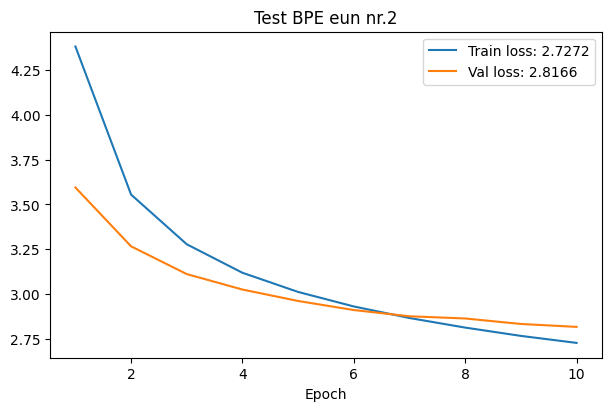

In [11]:
trainer = Trainer.TrainerModule(batch_size=64)
trainer.plotter_init("Test BPE eun nr.2")
trainer.fit(model, train_data, val_data, 10, '../checkpoints/checkpoint_bpe2.pt')

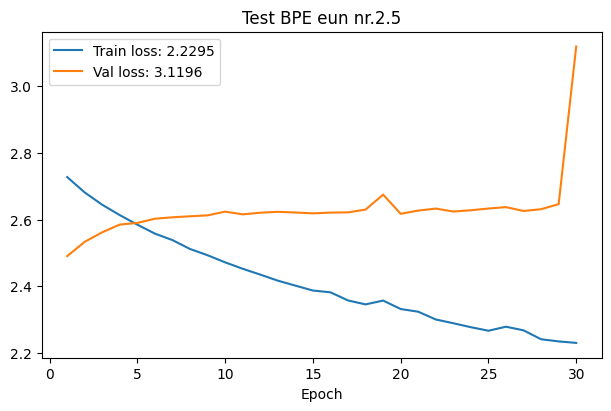

In [115]:
trainer.fit(model, train_data, val_data, 30, '../checkpoints/checkpoint_bpe2_5.pt')

In [14]:
encoder_eng = BPEEncoder(tokenizer_eng.vocab)
encoder_pol = BPEEncoder(tokenizer_pol.vocab, 65, True)
rev_pol_encoder = {v: k for k, v in encoder_pol.vocab_encoder.items()}

In [48]:
def predict_step(snt_eng, model, max_len=34):
    device = model.device
    snt_ids = encoder_eng.encode_snt(snt_eng) + [2]
    
    src_eng = torch.tensor(snt_ids).reshape(1, -1).to(device)
    src_len = torch.tensor([len(snt_ids)]).reshape(-1, 1).to(device)
    
    bos_id, eos_id = tokenizer_pol.vocab['<bos>'], tokenizer_pol.vocab['<eos>']
    test_tab = []
    
    with torch.no_grad():
        model.eval()
        X_enc = model.encoder(src_eng, src_len)
        dec_state = model.decoder.init_state(X_enc, src_len)
        pred_ids = [torch.tensor(bos_id).reshape(1, -1).to(device)]

        for _ in range(max_len):
            Y_dec, dec_state = model.decoder(pred_ids[-1], dec_state)
            pred_ids.append(Y_dec.argmax(2))
            test_tab.append(Y_dec)
            if pred_ids[-1].item() == eos_id:
                break
    return [rev_pol_encoder[x.item()] for x in pred_ids], test_tab

In [120]:
sigma = [2, 3]
tab = [sigma.copy() for _ in range(3)]
tab[0].append(4)
tab

[[2, 3, 4], [2, 3], [2, 3]]

In [120]:
class PredictionModule():
    def __init__(self, model, encoder_eng, tokenizer_pol, alpha=0.6, max_len=34):
        self.model, self.device = model, model.device
        self.alpha, self.max_len = alpha, max_len
        self.encode_snt = encoder_eng.encode_snt
        self.rev_pol = {v: k for k, v in encoder_pol.vocab_encoder.items()}
        self.eos_id = tokenizer_pol.vocab['<eos>']
        self.bos_in = torch.tensor(tokenizer_pol.vocab['<bos>']).reshape(1, -1).to(self.device)

    def predict_snt(self, snt_eng, num_k=5):
        snt_ids = self.encode_snt(snt_eng) + [2]
        X_enc = torch.tensor(snt_ids).reshape(1, -1).to(self.device)
        val_len = torch.tensor([len(snt_ids)]).reshape(-1, 1).to(self.device)
        finished = []

        with torch.no_grad():
            self.model.eval()
            X_dec = self.model.encoder(X_enc, val_len)
            dec_state = self.model.decoder.init_state(X_dec, val_len)
            Y_dec, dec_state = self.model.decoder(self.bos_in, dec_state)
            vals, inds = torch.topk(F.log_softmax(Y_dec, 2), k=num_k, dim=2)
            
            states = [[X_dec, val_len, [c.clone() if c is not None else None for c in dec_state[2]]] for _ in range(num_k)]
            logs = [vals[:, :, i].item() for i in range(num_k)]
            seqs = [[inds[:, :, i].item()] for i in range(num_k)]

            for _ in range(self.max_len-1):
                rows = []
                for i in range(num_k):
                    tok = torch.tensor(seqs[i][-1]).reshape(1, -1).to(self.device)
                    Y_dec, states[i] = self.model.decoder(tok, states[i])
                    Y_log = F.log_softmax(Y_dec, 2).reshape(-1, )
                    rows.append(logs[i] + Y_log)
                scores = torch.stack(rows)
                vocab  = scores.shape[-1]
                
                vals, idxs = torch.topk(scores.view(-1), 2*num_k)
                new_seqs, new_logs, new_states = [], [], []
                for j in range(2*num_k):
                    rodzic = idxs[j].item() // vocab
                    token  = idxs[j].item() % vocab
                    
                    if token == self.eos_id:
                        seq = seqs[rodzic] + [token]
                        finished.append((seq, vals[j].item(), len(seq)))
                    else:
                        new_seqs.append(seqs[rodzic] + [token])
                        new_logs.append(vals[j].item())
                        new_states.append([X_dec, val_len, [c.clone() for c in states[rodzic][2]]])
                        if len(new_seqs) == num_k:
                            break
                            
                if not new_seqs or len(finished) >= num_k:
                    break
                seqs, logs, states = new_seqs, new_logs, new_states
                
        if not finished:
            finished = [(s, l, len(s)) for s, l in zip(seqs, logs)]
        best = max(finished, key=lambda h: h[1] / (h[2] ** self.alpha))
        return [self.rev_pol[t] for t in best[0] if t != self.eos_id], finished

In [125]:
predicter = PredictionModule(model, encoder_eng, tokenizer_pol, 0.5)

In [132]:
tab, fin = predicter.predict_snt("Have you ever seen something like that.", 5)
fin_2 = [[rev_pol_encoder[t] for t in x] for x, _, _ in fin]
print(tab, '\n')
for x in fin_2:
    print(x)

['widziałeś_', 'coś_', ',_', 'co_', 'kiedykolwiek_', 'widziałeś_', '._'] 

['widziałeś_', 'coś_', 'takiego_', '._', '<eos>']
['widziałeś_', 'coś_', ',_', 'co_', 'kiedykolwiek_', 'widziałeś_', '._', '<eos>']
['widziałeś_', 'coś_', ',_', 'czego_', 'kiedykolwiek_', 'widziałeś_', '._', '<eos>']
['widziałeś_', 'coś_', ',_', 'co_', 'kiedykolwiek_', 'widziałem_', '._', '<eos>']
['widziałeś_', 'coś_', ',_', 'czego_', 'kiedykolwiek_', 'widział_', '._', '<eos>']


In [68]:
import seaborn as sns

In [96]:
head_1 = predicter.model.decoder._attention_weights[1][0].reshape(4, 10).to('cpu')
head_2 = predicter.model.decoder._attention_weights[1][1].reshape(4, 10).to('cpu')